# Final Project

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df1 = pd.read_csv('claims1.csv')

# Insights

1. From the bar plot, when comparing the average claim-to-policy ratio between fraudulent and non-fraudulent claims, there wasn’t a big difference. Non-fraudulent claims had a slightly higher ratio overall. Therefore, fraud in this dataset wasn't necessarily linked to higher claim amounts.
2. After creating the claim_to_policy_ratio feature, the data showed that when a single claim was really large compared to the customer's policy history, it was more likely to be fraudulent.
3. Out of all three models, Logistic Regression performed the best with an F1 score of 0.71. That tells me the fraud patterns in this data are mostly linear.

Business Implications
The data shows that fraud tends to show up in predictable ways. Certain claim types, higher ratios, and consistent patterns show up and can be modeled. Using a model like Logistic Regression could help an insurance team catch potential fraud faster.

## Data Preprocessing

In [3]:
df1

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment
0,21868593,Driver error,Auto,No,Material only,Female,Platinum
1,75740424,Crime,Home,Unknown,Material only,Female,Silver
2,30308357,Other driver error,Auto,No,Material only,Female,Silver
3,47830476,Natural causes,Auto,No,Material only,Female,Silver
4,19269962,Crime,Auto,No,Material only,Male,Gold
...,...,...,...,...,...,...,...
1073,79539873,Other driver error,Auto,Yes,Material only,Female,Platinum
1074,42364152,Other causes,Home,No,Material only,Female,Silver
1075,19888166,Other driver error,Auto,Yes,Injury only,Male,Gold
1076,11256802,Other driver error,Auto,No,Material only,Female,Silver


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   claim_id        1078 non-null   int64 
 1   incident_cause  1078 non-null   object
 2   claim_area      1078 non-null   object
 3   police_report   1078 non-null   object
 4   claim_type      1078 non-null   object
 5   gender          1078 non-null   object
 6   segment         1078 non-null   object
dtypes: int64(1), object(6)
memory usage: 59.1+ KB


In [5]:
df2 = pd.read_csv('claims2.csv')

In [6]:
df2

,CLAIMID,claim_amount,total_policy_claims,fraudulent
0,21868593,2980.0,1.0,False
1,75740424,2980.0,3.0,False
2,30308357,3369.5,1.0,True
3,47830476,1680.0,1.0,False
4,19269962,2680.0,1.0,False
...,...,...,...,...
1073,79539873,1770.0,1.0,False
1074,42364152,2800.0,1.0,False
1075,19888166,33080.0,2.0,False
1076,11256802,2840.0,4.0,False


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CLAIMID              1078 non-null   int64  
 1   claim_amount         1013 non-null   float64
 2   total_policy_claims  1068 non-null   float64
 3   fraudulent           1078 non-null   bool   
dtypes: bool(1), float64(2), int64(1)
memory usage: 26.4 KB


In [8]:
df2 = df2.rename(columns={'CLAIMID':'claim_id'})

In [9]:
df2

,claim_id,claim_amount,total_policy_claims,fraudulent
0,21868593,2980.0,1.0,False
1,75740424,2980.0,3.0,False
2,30308357,3369.5,1.0,True
3,47830476,1680.0,1.0,False
4,19269962,2680.0,1.0,False
...,...,...,...,...
1073,79539873,1770.0,1.0,False
1074,42364152,2800.0,1.0,False
1075,19888166,33080.0,2.0,False
1076,11256802,2840.0,4.0,False


In [10]:
df_concat = pd.concat([df1, df2])

In [11]:
df_concat

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment,claim_amount,total_policy_claims,fraudulent
0,21868593,Driver error,Auto,No,Material only,Female,Platinum,NaN,NaN,NaN
1,75740424,Crime,Home,Unknown,Material only,Female,Silver,NaN,NaN,NaN
2,30308357,Other driver error,Auto,No,Material only,Female,Silver,NaN,NaN,NaN
3,47830476,Natural causes,Auto,No,Material only,Female,Silver,NaN,NaN,NaN
4,19269962,Crime,Auto,No,Material only,Male,Gold,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1073,79539873,NaN,NaN,NaN,NaN,NaN,NaN,1770.0,1.0,False
1074,42364152,NaN,NaN,NaN,NaN,NaN,NaN,2800.0,1.0,False
1075,19888166,NaN,NaN,NaN,NaN,NaN,NaN,33080.0,2.0,False
1076,11256802,NaN,NaN,NaN,NaN,NaN,NaN,2840.0,4.0,False


In [12]:
df_merged = pd.merge(df1, df2, on='claim_id', how='inner')


In [13]:
df_merged

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment,claim_amount,total_policy_claims,fraudulent
0,21868593,Driver error,Auto,No,Material only,Female,Platinum,2980.0,1.0,False
1,75740424,Crime,Home,Unknown,Material only,Female,Silver,2980.0,3.0,False
2,30308357,Other driver error,Auto,No,Material only,Female,Silver,3369.5,1.0,True
3,47830476,Natural causes,Auto,No,Material only,Female,Silver,1680.0,1.0,False
4,19269962,Crime,Auto,No,Material only,Male,Gold,2680.0,1.0,False
...,...,...,...,...,...,...,...,...,...,...
1073,79539873,Other driver error,Auto,Yes,Material only,Female,Platinum,1770.0,1.0,False
1074,42364152,Other causes,Home,No,Material only,Female,Silver,2800.0,1.0,False
1075,19888166,Other driver error,Auto,Yes,Injury only,Male,Gold,33080.0,2.0,False
1076,11256802,Other driver error,Auto,No,Material only,Female,Silver,2840.0,4.0,False


In [14]:
df_merged.describe()

,claim_id,claim_amount,total_policy_claims
count,1.078000e+03,1013.000000,1068.000000
mean,5.078005e+07,12470.498519,1.582397
std,2.851431e+07,13788.245052,1.139620
min,1.545570e+05,1000.000000,1.000000
25%,2.646025e+07,1870.000000,1.000000
50%,4.979007e+07,2740.000000,1.000000
75%,7.606923e+07,24220.000000,2.000000
max,9.996199e+07,48150.500000,8.000000


In [15]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1078 non-null   int64  
 1   incident_cause       1078 non-null   object 
 2   claim_area           1078 non-null   object 
 3   police_report        1078 non-null   object 
 4   claim_type           1078 non-null   object 
 5   gender               1078 non-null   object 
 6   segment              1078 non-null   object 
 7   claim_amount         1013 non-null   float64
 8   total_policy_claims  1068 non-null   float64
 9   fraudulent           1078 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(6)
memory usage: 77.0+ KB


In [16]:
df_merged = df_merged.dropna()


In [17]:
df_merged['gender'].value_counts()

gender
Male      511
Female    493
Name: count, dtype: int64

<Axes: xlabel='total_policy_claims', ylabel='gender'>

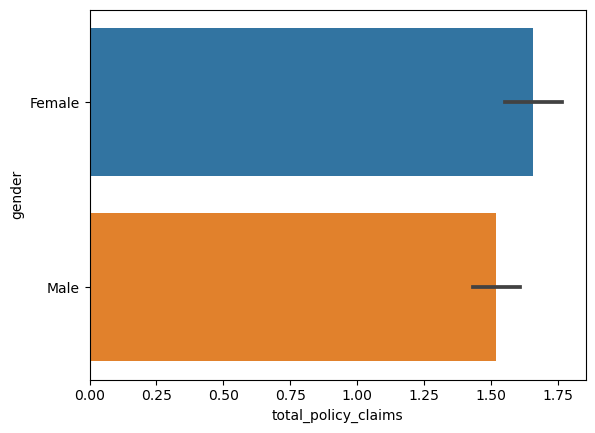

In [18]:
sns.barplot(data=df_merged, x='total_policy_claims', y='gender')


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='claim_amount', ylabel='Count'>

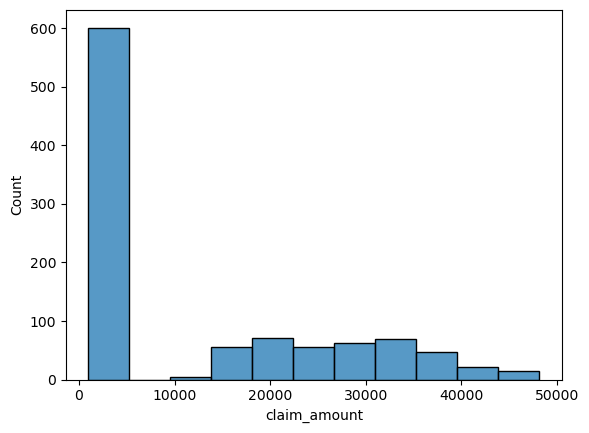

In [19]:
sns.histplot(data=df_merged, x='claim_amount')

In [20]:

q3 = df_merged['claim_amount'].quantile(0.75)
q1 = df_merged['claim_amount'].quantile(0.25)
iqr = q3 - q1
upper_limit = q3 + 3 * iqr
lower_limit = q1 - 3 * iqr


df_merged[(df_merged['claim_amount'] > upper_limit) | (df_merged['claim_amount'] < lower_limit)]


df_merged[(df_merged['claim_amount'] > upper_limit) | (df_merged['claim_amount'] < lower_limit)].count()


claim_id               0
incident_cause         0
claim_area             0
police_report          0
claim_type             0
gender                 0
segment                0
claim_amount           0
total_policy_claims    0
fraudulent             0
dtype: int64

In [21]:
q3 = df_merged['total_policy_claims'].quantile(0.75)
q1 = df_merged['total_policy_claims'].quantile(0.25)
iqr = q3 - q1
upper_limit = q3 + 3 * iqr
lower_limit = q1 - 3 * iqr

# Show and count extreme outliers
df_merged[(df_merged['total_policy_claims'] > upper_limit) | 
          (df_merged['total_policy_claims'] < lower_limit)]

df_merged[(df_merged['total_policy_claims'] > upper_limit) | 
          (df_merged['total_policy_claims'] < lower_limit)].count()

claim_id               11
incident_cause         11
claim_area             11
police_report          11
claim_type             11
gender                 11
segment                11
claim_amount           11
total_policy_claims    11
fraudulent             11
dtype: int64

In [22]:
conditions = [
    df_merged['total_policy_claims'] > upper_limit,
    df_merged['total_policy_claims'] < lower_limit
]
values = [
    df_merged['total_policy_claims'].median(),
    df_merged['total_policy_claims'].median()
]
df_merged['total_policy_claims'] = np.select(conditions, values, default=df_merged['total_policy_claims'])

/tmp/ipykernel_825/1768976634.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['total_policy_claims'] = np.select(conditions, values, default=df_merged['total_policy_claims'])


In [23]:
df_merged

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment,claim_amount,total_policy_claims,fraudulent
0,21868593,Driver error,Auto,No,Material only,Female,Platinum,2980.0,1.0,False
1,75740424,Crime,Home,Unknown,Material only,Female,Silver,2980.0,3.0,False
2,30308357,Other driver error,Auto,No,Material only,Female,Silver,3369.5,1.0,True
3,47830476,Natural causes,Auto,No,Material only,Female,Silver,1680.0,1.0,False
4,19269962,Crime,Auto,No,Material only,Male,Gold,2680.0,1.0,False
...,...,...,...,...,...,...,...,...,...,...
1073,79539873,Other driver error,Auto,Yes,Material only,Female,Platinum,1770.0,1.0,False
1074,42364152,Other causes,Home,No,Material only,Female,Silver,2800.0,1.0,False
1075,19888166,Other driver error,Auto,Yes,Injury only,Male,Gold,33080.0,2.0,False
1076,11256802,Other driver error,Auto,No,Material only,Female,Silver,2840.0,4.0,False


### Exploratory Data Analysis

In [24]:
df_merged['claim_to_policy_ratio'] = df_merged['claim_amount'] / (df_merged['total_policy_claims'] + 1)


/tmp/ipykernel_825/874120209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['claim_to_policy_ratio'] = df_merged['claim_amount'] / (df_merged['total_policy_claims'] + 1)


In [25]:
df_merged

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment,claim_amount,total_policy_claims,fraudulent,claim_to_policy_ratio
0,21868593,Driver error,Auto,No,Material only,Female,Platinum,2980.0,1.0,False,1490.000000
1,75740424,Crime,Home,Unknown,Material only,Female,Silver,2980.0,3.0,False,745.000000
2,30308357,Other driver error,Auto,No,Material only,Female,Silver,3369.5,1.0,True,1684.750000
3,47830476,Natural causes,Auto,No,Material only,Female,Silver,1680.0,1.0,False,840.000000
4,19269962,Crime,Auto,No,Material only,Male,Gold,2680.0,1.0,False,1340.000000
...,...,...,...,...,...,...,...,...,...,...,...
1073,79539873,Other driver error,Auto,Yes,Material only,Female,Platinum,1770.0,1.0,False,885.000000
1074,42364152,Other causes,Home,No,Material only,Female,Silver,2800.0,1.0,False,1400.000000
1075,19888166,Other driver error,Auto,Yes,Injury only,Male,Gold,33080.0,2.0,False,11026.666667
1076,11256802,Other driver error,Auto,No,Material only,Female,Silver,2840.0,4.0,False,568.000000


In [26]:
conditions = [
    df_merged['claim_amount'] > 20000,
    df_merged['claim_amount'] <= 20000
]
values = ['High Value', 'Low Value']

df_merged['claim_category'] = np.select(conditions, values)

/tmp/ipykernel_825/4142850511.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['claim_category'] = np.select(conditions, values)


In [27]:
df_merged

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment,claim_amount,total_policy_claims,fraudulent,claim_to_policy_ratio,claim_category
0,21868593,Driver error,Auto,No,Material only,Female,Platinum,2980.0,1.0,False,1490.000000,Low Value
1,75740424,Crime,Home,Unknown,Material only,Female,Silver,2980.0,3.0,False,745.000000,Low Value
2,30308357,Other driver error,Auto,No,Material only,Female,Silver,3369.5,1.0,True,1684.750000,Low Value
3,47830476,Natural causes,Auto,No,Material only,Female,Silver,1680.0,1.0,False,840.000000,Low Value
4,19269962,Crime,Auto,No,Material only,Male,Gold,2680.0,1.0,False,1340.000000,Low Value
...,...,...,...,...,...,...,...,...,...,...,...,...
1073,79539873,Other driver error,Auto,Yes,Material only,Female,Platinum,1770.0,1.0,False,885.000000,Low Value
1074,42364152,Other causes,Home,No,Material only,Female,Silver,2800.0,1.0,False,1400.000000,Low Value
1075,19888166,Other driver error,Auto,Yes,Injury only,Male,Gold,33080.0,2.0,False,11026.666667,High Value
1076,11256802,Other driver error,Auto,No,Material only,Female,Silver,2840.0,4.0,False,568.000000,Low Value


In [28]:
df_merged.describe()

,claim_id,claim_amount,total_policy_claims,claim_to_policy_ratio
count,1.004000e+03,1004.000000,1004.000000,1004.000000
mean,5.061961e+07,12455.761952,1.525896,5486.142654
std,2.857081e+07,13774.882055,1.021370,6349.971574
min,2.632040e+05,1000.000000,1.000000,181.666667
25%,2.612348e+07,1868.250000,1.000000,779.062500
50%,4.946419e+07,2740.000000,1.000000,1297.250000
75%,7.594951e+07,24260.000000,2.000000,10177.500000
max,9.996199e+07,48150.500000,5.000000,24017.750000


<Axes: xlabel='fraudulent_True', ylabel='claim_to_policy_ratio'>

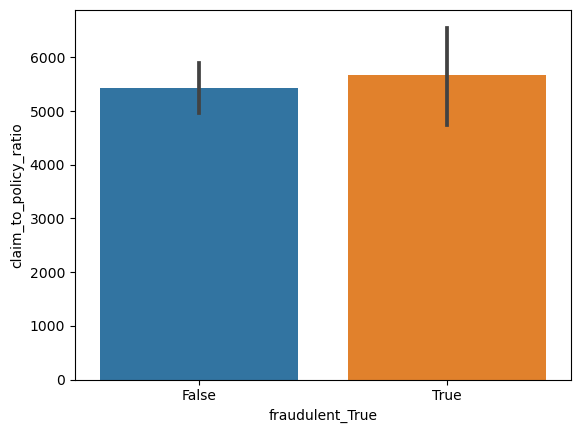

In [80]:
sns.barplot(data=df_merged, x='fraudulent_True', y='claim_to_policy_ratio')


In [78]:
X = df_merged.drop(columns=['fraudulent_True', 'claim_id'])
y = df_merged['fraudulent_True']

In [31]:
df_merged = pd.get_dummies(df_merged, columns=['fraudulent'], drop_first=True)

In [32]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1004 entries, 0 to 1077
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   claim_id               1004 non-null   int64  
 1   incident_cause         1004 non-null   object 
 2   claim_area             1004 non-null   object 
 3   police_report          1004 non-null   object 
 4   claim_type             1004 non-null   object 
 5   gender                 1004 non-null   object 
 6   segment                1004 non-null   object 
 7   claim_amount           1004 non-null   float64
 8   total_policy_claims    1004 non-null   float64
 9   claim_to_policy_ratio  1004 non-null   float64
 10  claim_category         1004 non-null   object 
 11  fraudulent_True        1004 non-null   bool   
dtypes: bool(1), float64(3), int64(1), object(7)
memory usage: 95.1+ KB


In [33]:
df_merged

,claim_id,incident_cause,claim_area,police_report,claim_type,gender,segment,claim_amount,total_policy_claims,claim_to_policy_ratio,claim_category,fraudulent_True
0,21868593,Driver error,Auto,No,Material only,Female,Platinum,2980.0,1.0,1490.000000,Low Value,False
1,75740424,Crime,Home,Unknown,Material only,Female,Silver,2980.0,3.0,745.000000,Low Value,False
2,30308357,Other driver error,Auto,No,Material only,Female,Silver,3369.5,1.0,1684.750000,Low Value,True
3,47830476,Natural causes,Auto,No,Material only,Female,Silver,1680.0,1.0,840.000000,Low Value,False
4,19269962,Crime,Auto,No,Material only,Male,Gold,2680.0,1.0,1340.000000,Low Value,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1073,79539873,Other driver error,Auto,Yes,Material only,Female,Platinum,1770.0,1.0,885.000000,Low Value,False
1074,42364152,Other causes,Home,No,Material only,Female,Silver,2800.0,1.0,1400.000000,Low Value,False
1075,19888166,Other driver error,Auto,Yes,Injury only,Male,Gold,33080.0,2.0,11026.666667,High Value,False
1076,11256802,Other driver error,Auto,No,Material only,Female,Silver,2840.0,4.0,568.000000,Low Value,False


In [34]:
df_merged = pd.get_dummies(df_merged, columns=['incident_cause'], drop_first=True)

In [35]:
df_merged = pd.get_dummies(df_merged, columns=['claim_area'], drop_first=True)

In [36]:
df_merged = pd.get_dummies(df_merged, columns=['police_report'], drop_first=True)

In [37]:
df_merged = pd.get_dummies(df_merged, columns=['claim_type'], drop_first=True)

In [38]:
df_merged = pd.get_dummies(df_merged, columns=['gender'], drop_first=True)

In [39]:
df_merged['segment'] = df_merged['segment'].replace('Platinum', 1, regex=False)
df_merged['segment'] = df_merged['segment'].replace('Gold', 2, regex=False)
df_merged['segment'] = df_merged['segment'].replace('Silver', 3, regex=False)

In [40]:
df_merged['claim_category'] = df_merged['claim_category'].replace('High Value', 1, regex=False)
df_merged['claim_category'] = df_merged['claim_category'].replace('Low Value', 2, regex=False)

### Comparison

In [41]:
y = df_merged['fraudulent_True']

In [42]:
X = df_merged.drop(columns=['fraudulent_True'])

In [43]:
X = StandardScaler().fit_transform(X)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

In [45]:
model = LogisticRegression().fit(X_train, y_train)

In [46]:
y_predictions = model.predict(X_test)

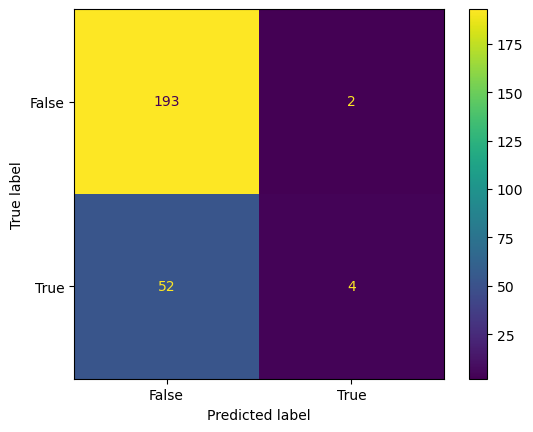

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)

In [48]:
f1_score(y_test, y_predictions, average='weighted')

0.710334614620696

In [50]:
df_merged['Fraud_Predicted'] = model.predict(X)

In [52]:
df_merged

,claim_id,segment,claim_amount,total_policy_claims,claim_to_policy_ratio,claim_category,fraudulent_True,incident_cause_Driver error,incident_cause_Natural causes,incident_cause_Other causes,incident_cause_Other driver error,claim_area_Home,police_report_Unknown,police_report_Yes,claim_type_Material and injury,claim_type_Material only,gender_Male,Fraud_Predicted
0,21868593,1,2980.0,1.0,1490.000000,2,False,True,False,False,False,False,False,False,False,True,False,False
1,75740424,3,2980.0,3.0,745.000000,2,False,False,False,False,False,True,True,False,False,True,False,False
2,30308357,3,3369.5,1.0,1684.750000,2,True,False,False,False,True,False,False,False,False,True,False,False
3,47830476,3,1680.0,1.0,840.000000,2,False,False,True,False,False,False,False,False,False,True,False,False
4,19269962,2,2680.0,1.0,1340.000000,2,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1073,79539873,1,1770.0,1.0,885.000000,2,False,False,False,False,True,False,False,True,False,True,False,False
1074,42364152,3,2800.0,1.0,1400.000000,2,False,False,False,True,False,True,False,False,False,True,False,False
1075,19888166,2,33080.0,2.0,11026.666667,1,False,False,False,False,True,False,False,True,False,False,True,False
1076,11256802,3,2840.0,4.0,568.000000,2,False,False,False,False,True,False,False,False,False,True,False,False


In [56]:
df_merged.to_csv('out_fraud_logisticregression.csv', index=False)

In [57]:
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)

In [58]:
y_predictions = model.predict(X_test)

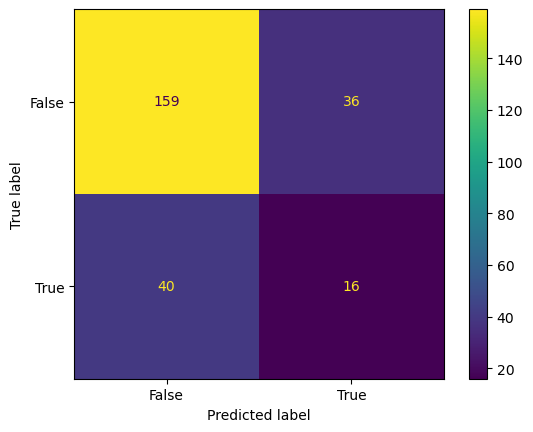

In [59]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)

In [60]:
f1_score(y_test, y_predictions, average='weighted')

0.6931409537634385

In [63]:
df_merged['Fraud_Predicted'] = model.predict(X)

In [65]:
df_merged.to_csv('out_fraud_decisiontree.csv', index=False)

In [66]:
model = KNeighborsClassifier().fit(X_train, y_train)

In [67]:
y_predictions = model.predict(X_test)

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/joblib/externals/loky/backend/context.py", line 217, in _count_physical_cores
    raise ValueError(


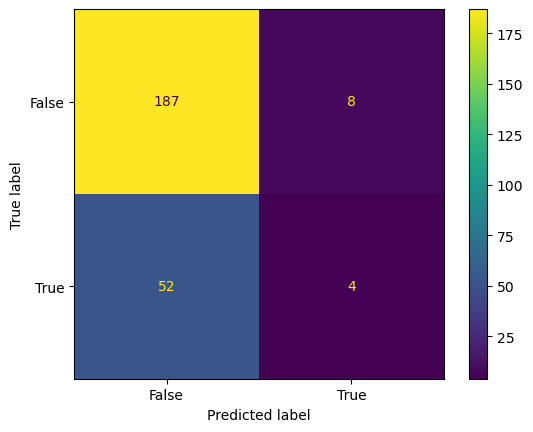

In [68]:
ConfusionMatrixDisplay.from_predictions(y_test, y_predictions)

In [72]:
f1_score(y_test, y_predictions, average='weighted')

0.6957358962091456